### TO DO

In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample
import utils as u

/home/fainx/micromamba/envs/xav_2412/lib/python3.11/site-packages/pyproj/__init__.py:95: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [5]:
year_list = ["2003"]#,"2004","2005","2006","2007","2008","2009","2010","2011","2012","2013"]
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

In [6]:
# Domain study: Fedchenko, GRa
longitude=slice(66,78)
latitude=slice(36,42)
# temp_HMA=ds.sel(lat=lat,lon=lon)

#### Load MAR outputs

In [7]:
# MAR topography
coord = xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRa_Fedchenko.nc')
lon = coord.LON
lat = coord.LAT
H = coord.SH

In [8]:
# MAR dataset
folder = '/bettik/amoryc/MARout/GRf/spin3/work/'

# Surface temperature
t2m_yr = xr.open_dataset(folder+'year-TT-MARv3.14_ER5-2003-2013.nc')
t2m_mon = xr.open_dataset(folder+'mon-TT-MARv3.14_ER5-2003-2013.nc')

# Rain
wpr_yr = xr.open_dataset(folder+ 'year-RF-MARv3.14_ER5-2003-2013.nc')
wpr_mon = xr.open_dataset(folder+ 'mon-RF-MARv3.14_ER5-2003-2013.nc')

# Snow fall
spr_yr = xr.open_dataset(folder+ 'year-SF-MARv3.14_ER5-2003-2013.nc')
spr_mon = xr.open_dataset(folder+ 'mon-SF-MARv3.14_ER5-2003-2013.nc')

# Snow height
sh_yr = xr.open_dataset(folder+ 'year-SHSN3-MARv3.14_ER5-2003-2013.nc')
sh_mon = xr.open_dataset(folder+ 'mon-SHSN3-MARv3.14_ER5-2003-2013.nc')

### Load Observations

In [9]:
# CRU, APHRODITE SNOW-CCI => Maria a déjà tout sur Spirit

In [10]:
# CRU : Surface mean/min/max températures, clouds
folder_cru='/bettik/PROJECTS/pr-regional-climate/observations/CRU/'

tmp_cru = xr.open_mfdataset(folder_cru + '*.tmp.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).load()
tmn_cru = xr.open_mfdataset(folder_cru + '*.tmn.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).tmn.load()
tmx_cru = xr.open_mfdataset(folder_cru + '*.tmx.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).tmx.load()
cld_cru = xr.open_mfdataset(folder_cru + '*.cld.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).cld.load()

### MAR interpolé sur grille CRU

In [11]:
lats = tmp_cru.lat
lons = tmp_cru.lon
t2m_yr_regrid = t2m_yr.interp(Y=lats).interp(X=lons)

/tmp/ipykernel_787513/3526299465.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(coord.LON, coord.LAT, t2m_mon.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r') #contourf


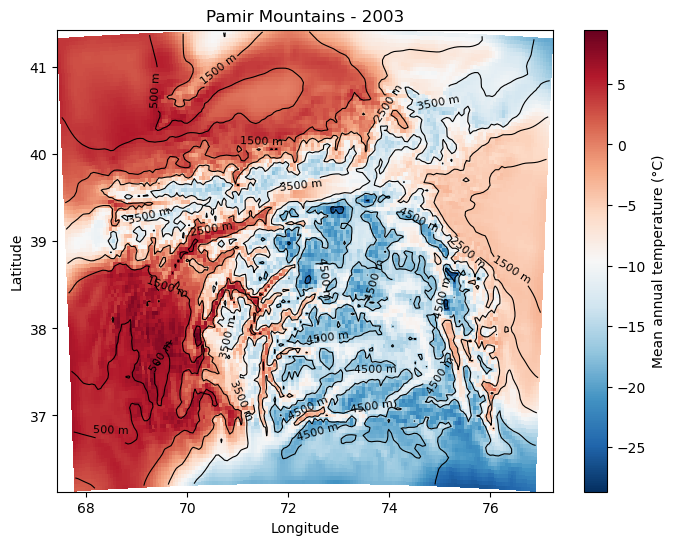

In [12]:
# Données MAR

plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(coord.LON, coord.LAT, t2m_mon.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r') #contourf

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)") #

plt.show()

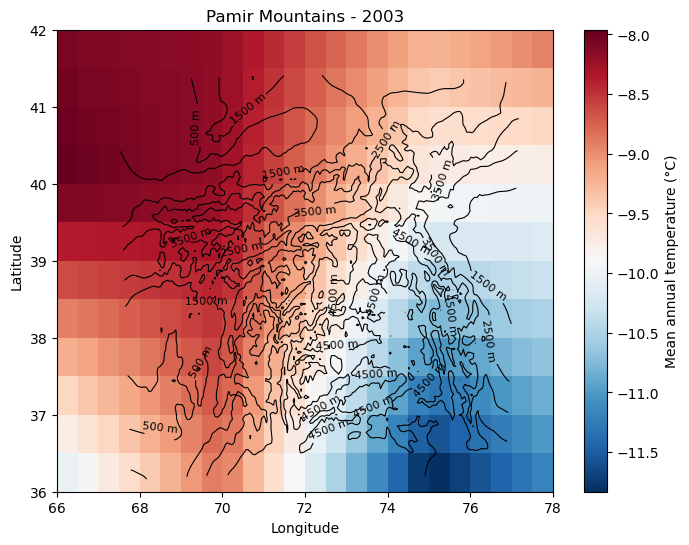

In [15]:
# Données MAR sur grille CRU

plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(t2m_yr_regrid.lon, t2m_yr_regrid.lat, t2m_yr_regrid.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)")

plt.show()

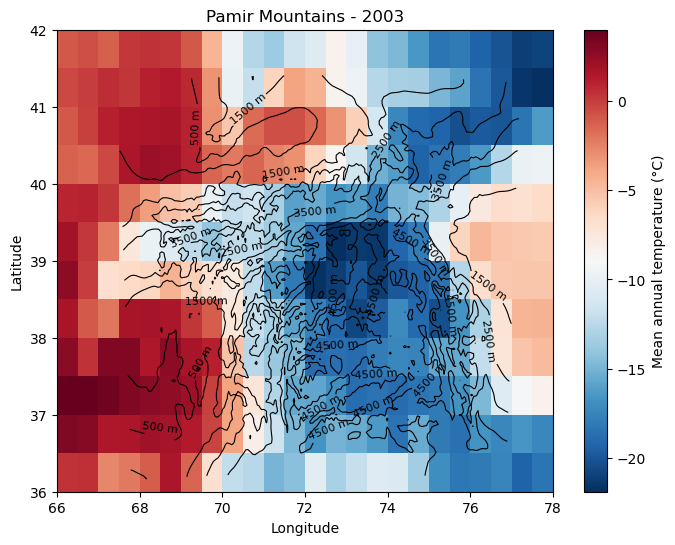

In [13]:
# Données CRU

plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(tmp_cru.lon, tmp_cru.lat, tmp_cru.tmp.isel(time=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)")

plt.show()

### CRU interpolé sur grille MAR

In [ ]:
lats_2 = coord.LAT 
lons_2 = coord.LON
tmp_cru_regrid = tmp_cru.interp(lat=lats_2).interp(lon=lons_2)
tmp_cru_regrid

In [ ]:
# Données CRU sur grille MAR

plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(coord.LON, coord.LAT, tmp_cru_regrid.tmp.isel(time=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)")

plt.show()

### CRU interpolé sur grille MAR puis réinterpolé sur grille CRU

In [ ]:
tmp_cru_regrid

In [ ]:
#ICI CA NE FONCTIONNE PAS

lats = tmp_cru.lat
lons = tmp_cru.lon

tmp_cru_2regrid = tmp_cru_regrid.interp(x=lons).interp(y=lats)

### CRU interpolé sur grille MAR avec Griddata

In [1]:
tmp_values = tmp_cru.isel(time=1).tmp.values.flatten()

NameError: name 'tmp_cru' is not defined

In [ ]:
grid_lon, grid_lat = np.meshgrid(coord.LON, coord.LAT)

In [2]:
lon = tmp_cru.lon.values.flatten()
lat = tmp_cru.lat.values.flatten()
(lon, lat)

NameError: name 'tmp_cru' is not defined

In [3]:
tmp_cru_griddata= griddata((tmp_cru.lon, tmp_cru.lat),tmp_cru.isel(time=1).tmp,(coord.LON,coord.LAT), method='linear')

NameError: name 'griddata' is not defined

In [41]:
print(tmp_cru.lon.shape, tmp_cru.lat.shape)

(24,) (12,)


In [36]:
(lon, lat)

(<xarray.DataArray 'LON' (y: 116, x: 164)> Size: 76kB
 array([[67.79164 , 67.847176, 67.90272 , ..., 76.75283 , 76.808365, 76.8639  ],
        [67.78897 , 67.844536, 67.90013 , ..., 76.75546 , 76.811035, 76.8666  ],
        [67.78631 , 67.8419  , 67.897514, ..., 76.7581  , 76.813705, 76.86931 ],
        ...,
        [67.45951 , 67.51911 , 67.57872 , ..., 77.080894, 77.140495, 77.20009 ],
        [67.45627 , 67.51591 , 67.575554, ..., 77.0841  , 77.14374 , 77.20338 ],
        [67.45302 , 67.5127  , 67.57239 , ..., 77.08731 , 77.14698 , 77.20667 ]],
       dtype=float32)
 Coordinates:
   * x        (x) float32 656B -405.0 -400.0 -395.0 -390.0 ... 400.0 405.0 410.0
   * y        (y) float32 464B -285.0 -280.0 -275.0 -270.0 ... 280.0 285.0 290.0
 Attributes:
     units:          degrees
     long_name:      Longitude
     standard_name:  Longitude
     actual_range:   [67.45302 77.20667]
     valid_range:    [-1.e+20  1.e+20],
 <xarray.DataArray 'LAT' (y: 116, x: 164)> Size: 76kB
 array([[

In [49]:
tmp_cru_griddata = griddata((lon, lat), tmp_values, (grid_lon, grid_lat), method='linear')

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (24,) and arg 1 with shape (12,).